# Customer Purchase Prediction Using Machine Learning
### A Marketing Analytics Case Study

Author: Emeka Henry Anumba  
Objective: Predict customer response to marketing campaigns using machine learning techniques.

## Introduction

In modern digital marketing, organizations rely on data-driven strategies to identify potential customers and improve campaign effectiveness. Predictive analytics allows companies to analyze customer data and anticipate purchasing behavior.

This project investigates whether machine learning models can predict a customer's likelihood of responding to a marketing campaign using demographic and behavioral data.

The analysis includes data preprocessing, exploratory data analysis, model development, and performance evaluation.

## Importing Required Libraries

The analysis relies on several Python libraries for data manipulation, visualization, and machine learning.

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

## Loading the Dataset

The dataset contains demographic and behavioral information about customers. It includes variables such as income level, marital status, purchasing behavior, and marketing campaign responses.

The target variable **Response** indicates whether a customer accepted a marketing campaign offer.

In [7]:
df = pd.read_csv("../data/marketing_campaign.csv", sep="\t")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## Initial Data Exploration

Before building predictive models, it is important to understand the structure of the dataset. This includes examining the number of observations, variable types, and potential missing values.

In [8]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


## Data Cleaning

Real-world datasets often contain missing or inconsistent values. These issues must be addressed before training machine learning models.

In this step we:
-  ⁠Remove missing values
-  ⁠Prepare categorical variables for modeling

In [9]:
df = df.dropna()
df = pd.get_dummies(df, drop_first=True)

## Exploratory Data Analysis

Exploratory analysis helps identify patterns in the dataset and provides insight into customer behavior.
In particular, we investigate relationships between income, web activity, and purchasing behavior.

#### Income Distribution

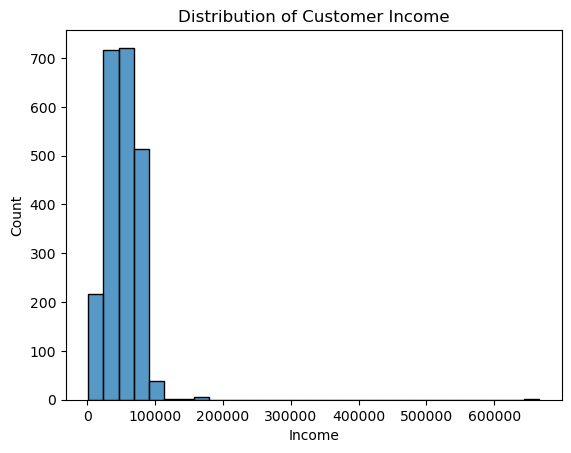

In [10]:
plt.figure()
sns.histplot(df["Income"], bins=30)
plt.title("Distribution of Customer Income")
plt.show()

#### Web Visits vs Purchase

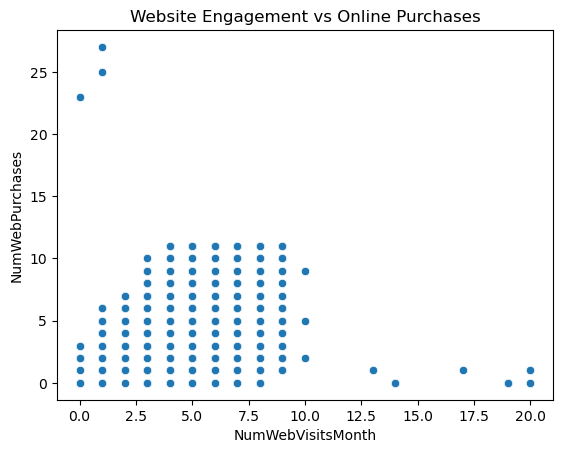

In [11]:
plt.figure()
sns.scatterplot(x=df["NumWebVisitsMonth"], y=df["NumWebPurchases"])
plt.title("Website Engagement vs Online Purchases")
plt.show()

Observation:

This visualization helps understand whether increased website engagement leads to more online purchases. While moderate website visits show a spread of purchases, extremely high visits often correspond to fewer purchases, suggesting that frequent visits alone do not guarantee higher conversions.

## Feature Selection

The dataset is divided into input variables (features) and the target variable.
Features represent customer attributes, while the target variable indicates whether the customer responded to the marketing campaign.

In [12]:
X = df.drop("Response", axis=1)
y = df["Response"]

## Splitting the Dataset

To evaluate model performance, the dataset is divided into a training set and a testing set. The training data is used to build the model, while the testing data evaluates predictive performance.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## Feature Scaling

Many machine learning algorithms perform better when input features are standardized. Feature scaling ensures that variables with larger values do not dominate the learning process.

In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Logistic Regression Model

Logistic regression is a widely used classification algorithm for predicting binary outcomes. In this project, it serves as a baseline model for predicting customer purchase behavior.

In [15]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
pred_log = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_log))
print(classification_report(y_test, pred_log))

Accuracy: 0.8513513513513513
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       378
           1       0.50      0.41      0.45        66

    accuracy                           0.85       444
   macro avg       0.70      0.67      0.68       444
weighted avg       0.84      0.85      0.85       444



## Random Forest Model

Random Forest is an ensemble learning method that combines multiple decision trees to improve predictive performance and reduce overfitting.

In [16]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, pred_rf))

Accuracy: 0.8761261261261262
ROC-AUC: 0.6208513708513709


## Feature Importance

Understanding which features influence the model's predictions is essential in marketing analytics. Feature importance scores indicate which variables contribute most to predicting customer purchase behavior.

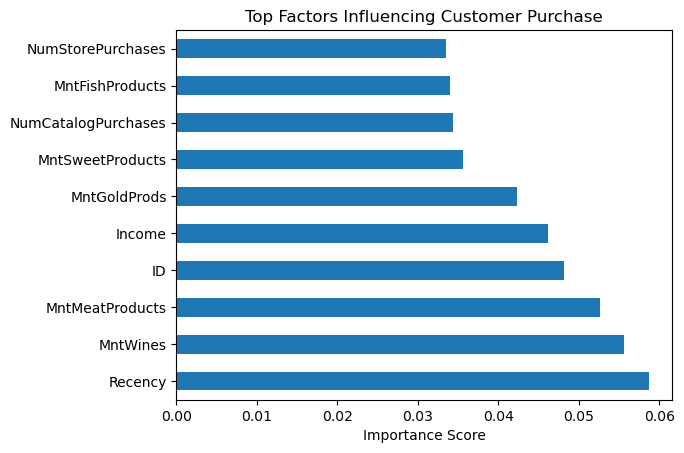

In [18]:
importance = rf_model.feature_importances_
features = pd.Series(importance, index=X.columns)

plt.figure()
features.nlargest(10).plot(kind="barh")

plt.title("Top Factors Influencing Customer Purchase")
plt.xlabel("Importance Score")
# Save BEFORE showing
plt.savefig("../visuals/feature_importance.png", bbox_inches="tight")

plt.show()

## Business Implications

The predictive model developed in this study can support marketing decision-making in several ways:

*  ⁠Target high-probability customers to improve campaign efficiency
*  ⁠Reduce marketing costs by avoiding low-response segments
*  ⁠Personalize customer engagement strategies based on behavior

For example, customers with high website engagement and previous purchase activity are more likely to respond to campaigns. Focusing on this segment can significantly increase return on investment (ROI).

## Conclusion

This project demonstrates the application of machine learning techniques to predict customer responses to marketing campaigns using demographic and behavioral data.

The findings suggest that while customer engagement—such as website visits—provides useful signals, it does not independently guarantee higher conversion. Instead, purchase behavior is influenced by a combination of factors, including past purchasing activity, income level, and overall interaction with marketing channels.

The Random Forest model showed strong predictive performance and highlighted the importance of multi-dimensional customer profiling. These results emphasize that effective marketing strategies should move beyond single metrics and adopt a more holistic, data-driven approach to customer segmentation and targeting.

Overall, this study illustrates how machine learning can support more precise and efficient marketing decision-making by identifying customers with a higher likelihood of responding to campaigns.

This project highlights the role of machine learning in bridging data analysis and strategic marketing decision-making.